In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("movies.csv")

In [3]:
df.head()


,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   object 
 6   genres        2000 non-null   object 
 7   success       2000 non-null   int64  
 8   main_genre    2000 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 140.8+ KB


In [48]:
import ast

def get_first_genre(x):
    try:
        genres = ast.literal_eval(x)
        if len(genres) > 0:
            return genres[0]["name"]
    except:
        return "Unknown"

df["main_genre"] = df["genres"].apply(get_first_genre)

In [49]:
df.shape

(2000, 9)

In [50]:
# Missing Values
df.isnull().sum()

budget            0
revenue           0
popularity        0
runtime           0
vote_average      0
title             0
genres            0
success           0
main_genre      181
dtype: int64

In [51]:
# Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [52]:
# Check Zero Budget
(df["budget"]==0).sum()

np.int64(0)

In [53]:
# Check Zero Revenue
(df["revenue"]==0).sum()

np.int64(0)

In [54]:
# Create Target Variable
df["success"]=(df["revenue"]>df["budget"]).astype(int)

In [55]:
# Check Class Balance
df["success"].value_counts()
df["success"].value_counts(normalize=True)

success
1    0.807
0    0.193
Name: proportion, dtype: float64


# STAGE 2 – Exploratory Data Analysis (EDA)

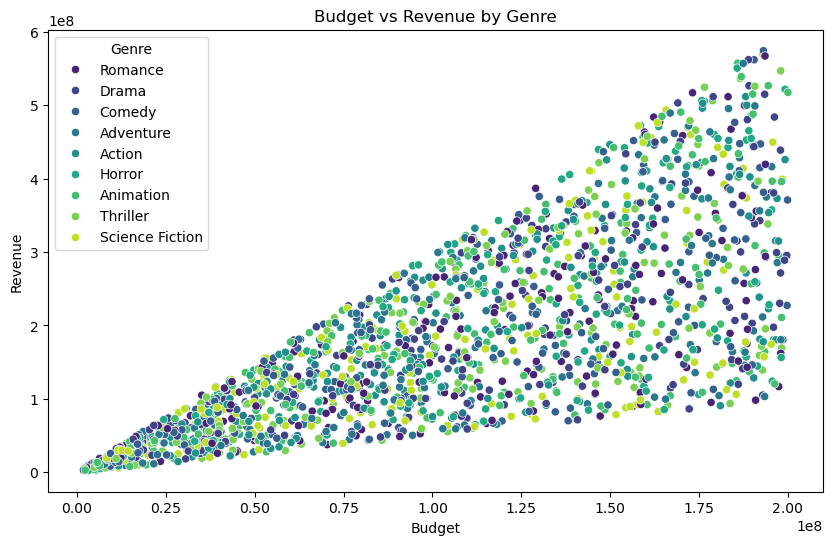

In [66]:
# Budget vs Revenue
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    hue="main_genre",
    palette="viridis"
)
plt.title("Budget vs Revenue by Genre")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.legend(title="Genre")
plt.show()

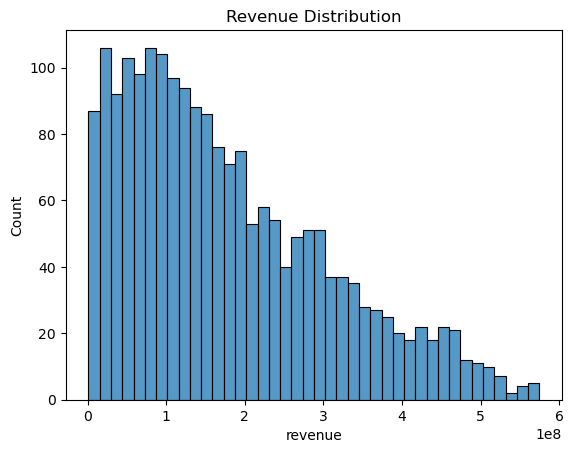

In [67]:
# Revenue Distribution
sns.histplot(df["revenue"],bins=40)
plt.title("Revenue Distribution")
plt.show()

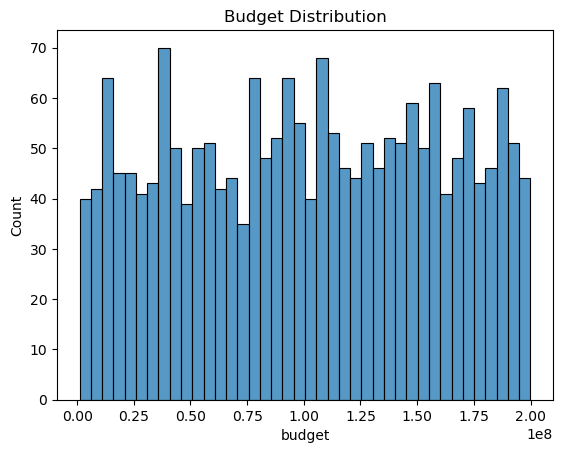

In [68]:
# Budget Distribution
sns.histplot(df["budget"],bins=40)
plt.title("Budget Distribution")
plt.show()

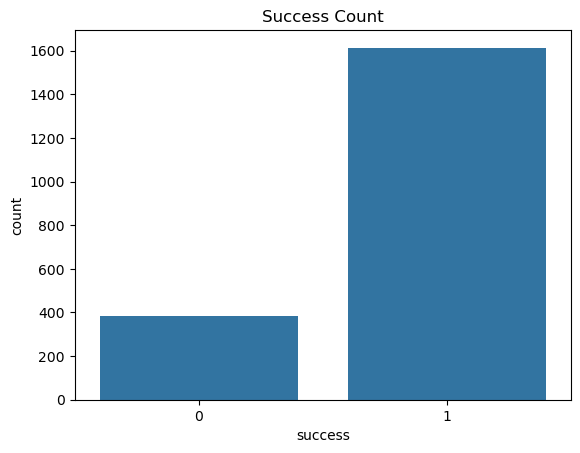

In [70]:
# Success Count
sns.countplot(data=df, x="success")
plt.title("Success Count")
plt.show()

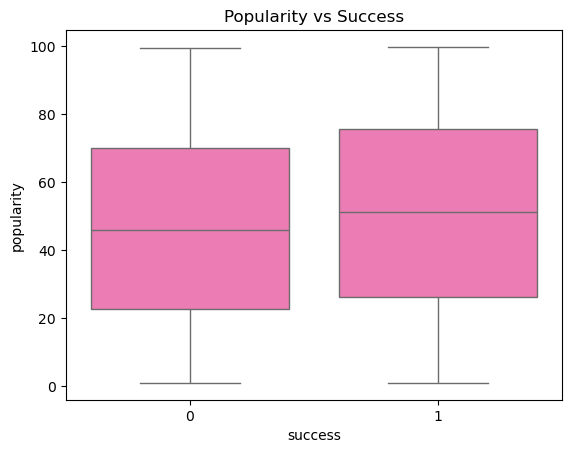

In [75]:
# Popularity vs Success
sns.boxplot(data=df, x="success", y="popularity", color="hotpink")
plt.title("Popularity vs Success")
plt.show()

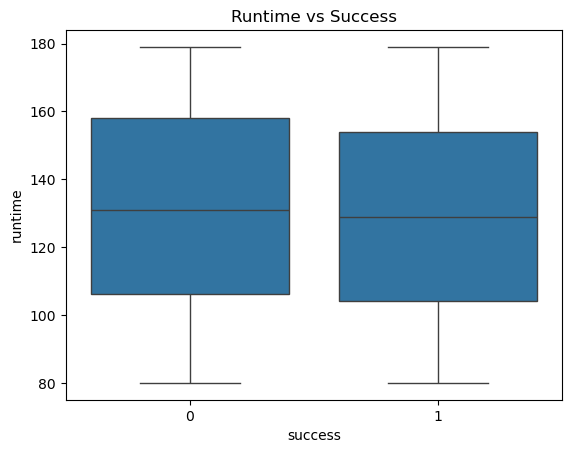

In [76]:
# Runtime vs Success
sns.boxplot(data=df, x="success", y="runtime")
plt.title("Runtime vs Success")
plt.show()

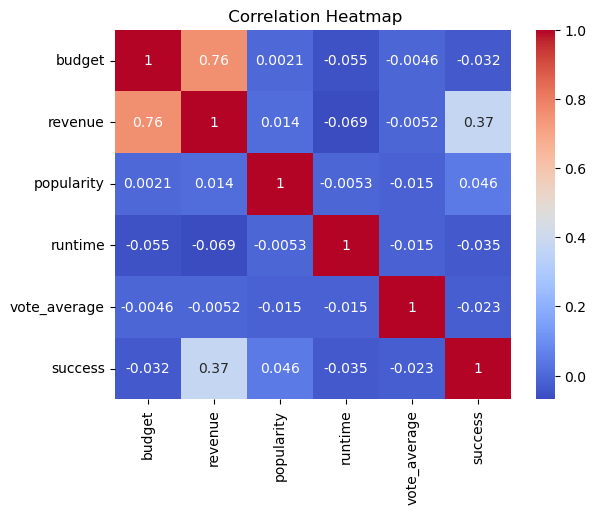

In [77]:
# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title(" Correlation Heatmap")
plt.show()

<Axes: xlabel='genres'>

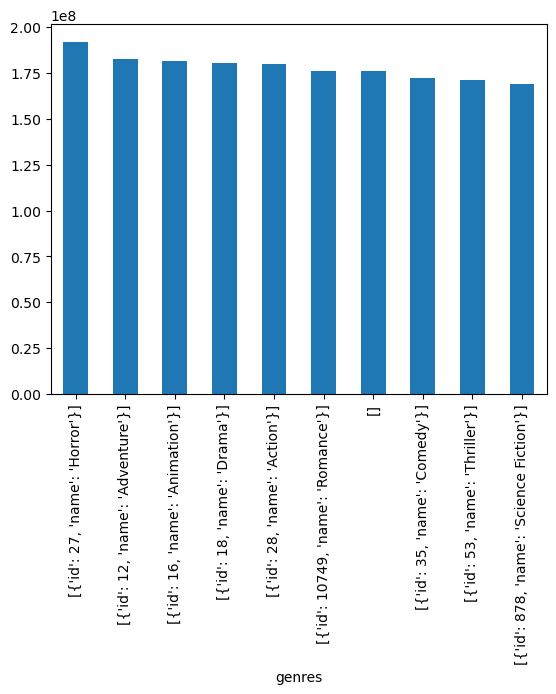

In [26]:
# Averege Revenue by genres
genre=df.groupby("genres")["revenue"].mean().sort_values(ascending=False).head(10)

genre.plot(kind="bar")